# Week 2 – Day 8-10: Feature Engineering + ML
**Model 1** — Customer Churn Predictor (XGBoost + SMOTE)  
**Model 2** — Low Review Predictor (LightGBM)  
Churn = no purchase in 90 days after customer's last order.

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from pathlib import Path
import pickle
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    classification_report, confusion_matrix, roc_auc_score
)
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
import lightgbm as lgb
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['figure.dpi'] = 110

DB_USER     = "olist_user"
DB_PASSWORD = "1234"
DB_HOST     = "localhost"
DB_PORT     = "5432"
DB_NAME     = "olist_db"

MODELS_DIR = Path("models")
MODELS_DIR.mkdir(exist_ok=True)

engine = create_engine(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}@{DB_HOST}:{DB_PORT}/{DB_NAME}",
    pool_pre_ping=True, echo=False
)
print("Connected.")

Connected.


## 2. Pull Raw Data

In [2]:
RAW_SQL = """
SELECT
    c.customer_unique_id,
    c.customer_state,
    o.order_id,
    o.order_purchase_timestamp,
    o.order_delivered_customer_date,
    o.order_estimated_delivery_date,
    o.order_status,
    oi.price,
    oi.freight_value,
    p.payment_type,
    p.payment_installments,
    p.payment_value,
    r.review_score,
    COALESCE(t.product_category_name_english, prod.product_category_name, 'unknown') AS category
FROM orders o
JOIN customers c ON c.customer_id = o.customer_id
JOIN order_items oi ON oi.order_id = o.order_id
JOIN payments p ON p.order_id = o.order_id AND p.payment_sequential = 1
LEFT JOIN reviews r ON r.order_id = o.order_id
LEFT JOIN products prod ON prod.product_id = oi.product_id
LEFT JOIN product_category_translation t
       ON t.product_category_name = prod.product_category_name
WHERE o.order_status = 'delivered'
"""

with engine.connect() as conn:
    raw = pd.read_sql(text(RAW_SQL), conn,
                      parse_dates=["order_purchase_timestamp",
                                   "order_delivered_customer_date",
                                   "order_estimated_delivery_date"])

print(f"Raw shape: {raw.shape}")
raw.head(3)

Raw shape: (110749, 14)


,customer_unique_id,customer_state,order_id,order_purchase_timestamp,order_delivered_customer_date,order_estimated_delivery_date,order_status,price,freight_value,payment_type,payment_installments,payment_value,review_score,category
0,708ab75d2a007f0564aedd11139c7708,MG,b81ef226f3fe1789b1e8b2acac839d17,2018-04-25 22:01:49,2018-05-09 17:36:51,2018-05-22,delivered,79.80,19.53,credit_card,8,99.33,1.0,home_construction
1,a8b9d3a27068454b1c98cc67d4e31e6f,SP,a9810da82917af2d9aefd1278f1dcfa0,2018-06-26 11:01:38,2018-06-29 20:32:09,2018-07-16,delivered,17.00,7.39,credit_card,1,24.39,5.0,auto
2,6f70c0b2f7552832ba46eb57b1c5651e,SP,25e8ea4e93396b6fa0d3dd708e76c1bd,2017-12-12 11:19:55,2017-12-18 17:24:41,2018-01-04,delivered,56.99,8.72,credit_card,1,65.71,5.0,perfumery


## 3. Feature Engineering

In [3]:
# reference date = day after latest order in dataset (simulate "today")
REF_DATE = raw["order_purchase_timestamp"].max() + pd.Timedelta(days=1)
CHURN_DAYS = 90
print(f"Reference date: {REF_DATE.date()}  |  Churn threshold: {CHURN_DAYS} days")

Reference date: 2018-08-30  |  Churn threshold: 90 days


In [4]:
# ── delivery delay (days, positive = late) ───────────────────────────────────
raw["delivery_delay"] = (
    raw["order_delivered_customer_date"] - raw["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

# ── per-order spend ───────────────────────────────────────────────────────────
raw["order_total"] = raw["price"] + raw["freight_value"]

# ── top category per customer (most ordered) ─────────────────────────────────
top_cat = (
    raw.groupby(["customer_unique_id", "category"])["order_id"]
    .count()
    .reset_index(name="cat_count")
    .sort_values("cat_count", ascending=False)
    .groupby("customer_unique_id")["category"]
    .first()
    .rename("top_category")
)

# ── top payment type per customer ─────────────────────────────────────────────
top_pay = (
    raw.groupby(["customer_unique_id", "payment_type"])["order_id"]
    .count()
    .reset_index(name="pay_count")
    .sort_values("pay_count", ascending=False)
    .groupby("customer_unique_id")["payment_type"]
    .first()
    .rename("top_payment_type")
)

print("Derived order-level columns.")

Derived order-level columns.


In [6]:
# ── aggregate to customer level ───────────────────────────────────────────────
cust = (
    raw.groupby("customer_unique_id")
    .agg(
        last_order_date      =("order_purchase_timestamp", "max"),
        first_order_date     =("order_purchase_timestamp", "min"),
        frequency            =("order_id",                 "nunique"),
        monetary             =("order_total",              "sum"),
        avg_order_value      =("order_total",              "mean"),
        avg_review_score     =("review_score",             "mean"),
        avg_delivery_delay   =("delivery_delay",           "mean"),
        pct_late_orders      =("delivery_delay",           lambda x: (x > 0).mean()),
        avg_installments     =("payment_installments",     "mean"),
        customer_state       =("customer_state",           "first"),
    )
    .reset_index()
)

# ── RFM: recency (days since last order) ──────────────────────────────────────
cust["recency"] = (REF_DATE - cust["last_order_date"]).dt.days

# ── customer tenure (days between first and last order) ───────────────────────
cust["tenure_days"] = (cust["last_order_date"] - cust["first_order_date"]).dt.days

# ── merge top category + top payment ──────────────────────────────────────────
cust = cust.merge(top_cat, on="customer_unique_id", how="left")
cust = cust.merge(top_pay, on="customer_unique_id", how="left")

# ── churn label ───────────────────────────────────────────────────────────────
cust["churned"] = (cust["recency"] > CHURN_DAYS).astype(int)

print(f"Customer features: {cust.shape}")
print(f"Churn rate: {cust['churned'].mean():.2%}")
cust.head(3)

Customer features: (93281, 16)
Churn rate: 80.23%


,customer_unique_id,last_order_date,first_order_date,frequency,monetary,avg_order_value,avg_review_score,avg_delivery_delay,pct_late_orders,avg_installments,customer_state,recency,tenure_days,top_category,top_payment_type,churned
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05-10 10:56:27,1,141.90,141.90,5.0,-4.132905,0.0,8.0,SP,112,0,bed_bath_table,credit_card,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05-07 11:11:27,1,27.19,27.19,4.0,-4.248125,0.0,1.0,SP,115,0,health_beauty,credit_card,1
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03-10 21:05:03,1,86.22,86.22,3.0,-1.389734,0.0,8.0,SC,537,0,stationery,credit_card,1


In [7]:
# ── feature stats ─────────────────────────────────────────────────────────────
FEATURE_COLS = [
    "frequency", "monetary", "avg_order_value",
    "avg_review_score", "avg_delivery_delay", "pct_late_orders",
    "avg_installments", "tenure_days",
    "customer_state", "top_category", "top_payment_type",
]

cust[FEATURE_COLS].describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
frequency,93281.0,NaN,NaN,NaN,1.033426,0.209082,1.0,1.0,1.0,1.0,15.0
monetary,93281.0,NaN,NaN,NaN,165.912556,227.829856,9.59,63.1,107.87,183.1,13664.08
avg_order_value,93281.0,NaN,NaN,NaN,146.010857,197.773511,9.341429,57.75,96.47,162.75,6929.31
avg_review_score,92679.0,NaN,NaN,NaN,4.153619,1.280334,1.0,4.0,5.0,5.0,5.0
avg_delivery_delay,93273.0,NaN,NaN,NaN,-11.152643,10.142653,-146.016123,-16.229248,-11.749259,-6.391296,188.975081
pct_late_orders,93281.0,NaN,NaN,NaN,0.081436,0.272069,0.0,0.0,0.0,0.0,1.0
avg_installments,93281.0,NaN,NaN,NaN,2.915541,2.692131,1.0,1.0,2.0,4.0,24.0
tenure_days,93281.0,NaN,NaN,NaN,2.632476,24.940385,0.0,0.0,0.0,0.0,633.0
customer_state,93281,27,SP,39117,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top_category,93281,74,bed_bath_table,8672,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 4. Preprocessing

In [8]:
df_model = cust[FEATURE_COLS + ["churned"]].copy()

# fill nulls
df_model["avg_review_score"].fillna(df_model["avg_review_score"].median(), inplace=True)
df_model["avg_delivery_delay"].fillna(0, inplace=True)
df_model["top_category"].fillna("unknown", inplace=True)
df_model["top_payment_type"].fillna("unknown", inplace=True)

# label-encode categoricals (XGBoost handles numerics)
cat_cols = ["customer_state", "top_category", "top_payment_type"]
encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))
    encoders[col] = le

X = df_model.drop(columns=["churned"])
y = df_model["churned"]

print(f"X shape: {X.shape}  |  class balance: {y.value_counts().to_dict()}")

X shape: (93281, 11)  |  class balance: {1: 74842, 0: 18439}


## 5. Train / Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}  |  Test: {X_test.shape}")
print(f"Train churn rate: {y_train.mean():.2%}  |  Test: {y_test.mean():.2%}")

Train: (74624, 11)  |  Test: (18657, 11)
Train churn rate: 80.23%  |  Test: 80.23%


## 6. SMOTE — Balance Training Set

In [10]:
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {dict(y_train.value_counts())}")
print(f"After  SMOTE: {dict(pd.Series(y_train_sm).value_counts())}")

Before SMOTE: {1: 59873, 0: 14751}
After  SMOTE: {0: 59873, 1: 59873}


## 7. XGBoost Churn Model

In [11]:
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="aucpr",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

xgb_model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_test, y_test)],
    verbose=50,
)

[0]	validation_0-aucpr:0.85138
[50]	validation_0-aucpr:0.86461
[100]	validation_0-aucpr:0.87696
[150]	validation_0-aucpr:0.88124
[200]	validation_0-aucpr:0.88533
[250]	validation_0-aucpr:0.88824
[299]	validation_0-aucpr:0.88970


,objective,'binary:logistic'
,use_label_encoder,False
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'aucpr'


## 8. Evaluation

In [12]:
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
y_pred       = (y_pred_proba >= 0.5).astype(int)

pr_auc  = average_precision_score(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"PR-AUC  : {pr_auc:.4f}")
print(f"ROC-AUC : {roc_auc:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["Not Churned", "Churned"]))

PR-AUC  : 0.8897
ROC-AUC : 0.6839

              precision    recall  f1-score   support

 Not Churned       0.46      0.19      0.27      3688
     Churned       0.83      0.94      0.88     14969

    accuracy                           0.80     18657
   macro avg       0.64      0.57      0.58     18657
weighted avg       0.75      0.80      0.76     18657



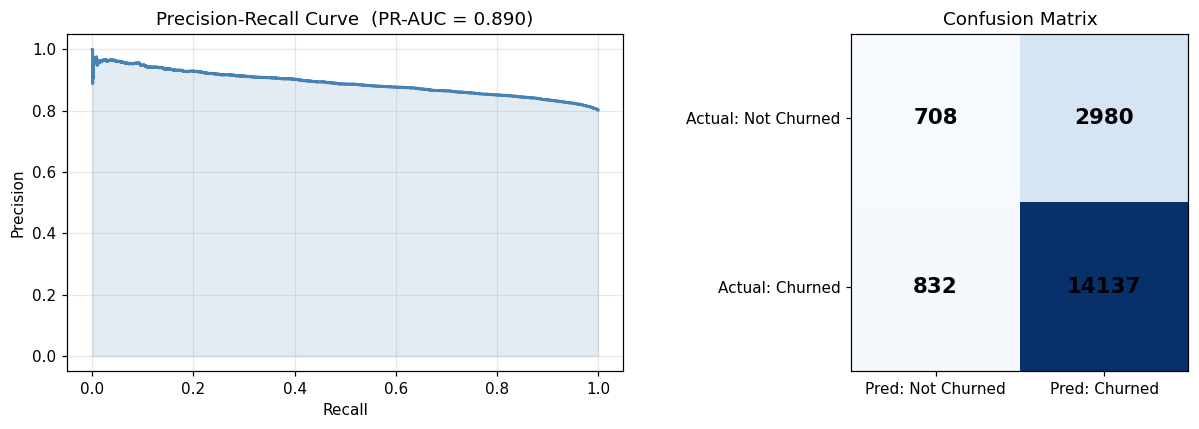

In [13]:
# ── precision-recall curve ────────────────────────────────────────────────────
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(recall, precision, lw=2, color="steelblue")
axes[0].fill_between(recall, precision, alpha=0.15, color="steelblue")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title(f"Precision-Recall Curve  (PR-AUC = {pr_auc:.3f})")
axes[0].grid(alpha=0.3)

# confusion matrix
cm = confusion_matrix(y_test, y_pred)
im = axes[1].imshow(cm, cmap="Blues")
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i, j], ha="center", va="center", fontsize=14, fontweight="bold")
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["Pred: Not Churned", "Pred: Churned"])
axes[1].set_yticklabels(["Actual: Not Churned", "Actual: Churned"])
axes[1].set_title("Confusion Matrix")

plt.tight_layout()
plt.savefig(MODELS_DIR / "churn_eval.png", bbox_inches="tight")
plt.show()

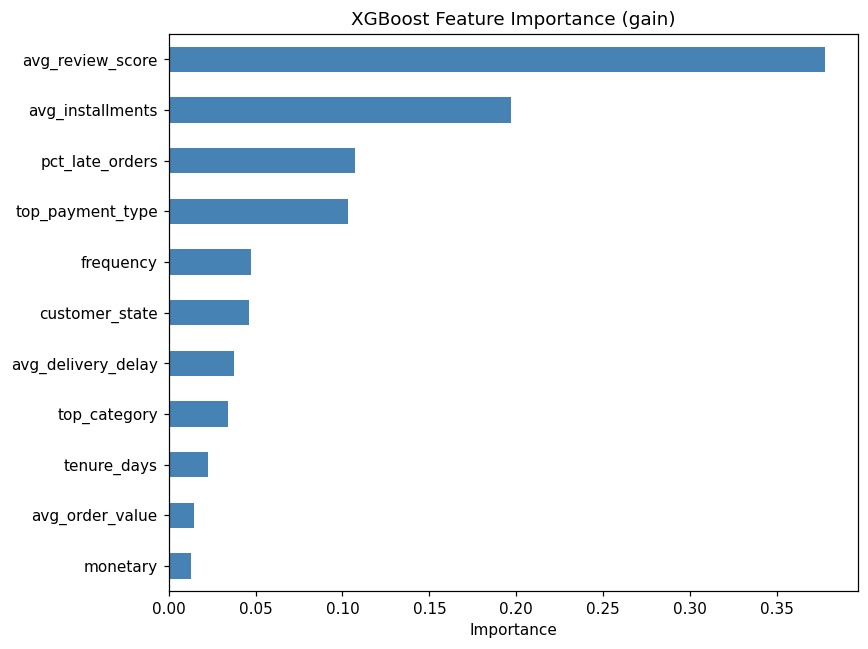

In [14]:
# ── feature importance ────────────────────────────────────────────────────────
feat_imp = pd.Series(
    xgb_model.feature_importances_, index=X.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
feat_imp.plot(kind="barh", ax=ax, color="steelblue")
ax.set_title("XGBoost Feature Importance (gain)")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(MODELS_DIR / "churn_feature_importance.png", bbox_inches="tight")
plt.show()

## 9. Save Churn Model Artifacts

In [15]:
import json

xgb_model.save_model(MODELS_DIR / "churn_xgb.json")

# save encoders + feature list for inference
artifacts = {
    "feature_cols": list(X.columns),
    "cat_cols":     cat_cols,
    "churn_days":   CHURN_DAYS,
    "ref_date":     str(REF_DATE.date()),
    "pr_auc":       round(pr_auc, 4),
    "roc_auc":      round(roc_auc, 4),
}
with open(MODELS_DIR / "churn_meta.json", "w") as f:
    json.dump(artifacts, f, indent=2)

with open(MODELS_DIR / "churn_encoders.pkl", "wb") as f:
    pickle.dump(encoders, f)

print("Saved: churn_xgb.json, churn_meta.json, churn_encoders.pkl")

Saved: churn_xgb.json, churn_meta.json, churn_encoders.pkl


---
## 10. Model 2 — Low Review Predictor (LightGBM)
Predicts whether an order will get a low review (1–2 stars).  
Features: delivery delay, price, freight, seller metrics, payment type.

In [16]:
# ── seller-level aggregates ───────────────────────────────────────────────────
seller_stats = (
    raw.groupby("order_id").agg(
        price           =("price",            "sum"),
        freight_value   =("freight_value",     "sum"),
        delivery_delay  =("delivery_delay",    "mean"),
        payment_type    =("payment_type",      "first"),
        payment_installments=("payment_installments", "mean"),
        review_score    =("review_score",      "first"),
        category        =("category",          "first"),
    ).reset_index()
    .dropna(subset=["review_score"])
)

seller_stats["low_review"] = (seller_stats["review_score"] <= 2).astype(int)
seller_stats["delivery_delay"].fillna(0, inplace=True)

print(f"Order-level review dataset: {seller_stats.shape}")
print(f"Low review rate: {seller_stats['low_review'].mean():.2%}")

Order-level review dataset: (95754, 9)
Low review rate: 12.80%


In [17]:
REV_FEATURES = ["price", "freight_value", "delivery_delay",
                "payment_installments", "payment_type", "category"]

df_rev = seller_stats[REV_FEATURES + ["low_review"]].copy()

rev_cat_cols = ["payment_type", "category"]
rev_encoders = {}
for col in rev_cat_cols:
    le = LabelEncoder()
    df_rev[col] = le.fit_transform(df_rev[col].astype(str))
    rev_encoders[col] = le

Xr = df_rev.drop(columns=["low_review"])
yr = df_rev["low_review"]

Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    Xr, yr, test_size=0.2, stratify=yr, random_state=42
)

smote_rev = SMOTE(random_state=42)
Xr_train_sm, yr_train_sm = smote_rev.fit_resample(Xr_train, yr_train)

print(f"Review model train: {Xr_train_sm.shape}")

Review model train: (133602, 6)


In [18]:
lgb_model = lgb.LGBMClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbose=-1,
)
lgb_model.fit(Xr_train_sm, yr_train_sm)

yr_proba = lgb_model.predict_proba(Xr_test)[:, 1]
yr_pred  = (yr_proba >= 0.5).astype(int)

rev_pr_auc  = average_precision_score(yr_test, yr_proba)
rev_roc_auc = roc_auc_score(yr_test, yr_proba)

print(f"Review PR-AUC  : {rev_pr_auc:.4f}")
print(f"Review ROC-AUC : {rev_roc_auc:.4f}")
print()
print(classification_report(yr_test, yr_pred, target_names=["Normal Review", "Low Review"]))

Review PR-AUC  : 0.3963
Review ROC-AUC : 0.6906

               precision    recall  f1-score   support

Normal Review       0.91      0.97      0.94     16700
   Low Review       0.62      0.31      0.42      2451

     accuracy                           0.89     19151
    macro avg       0.76      0.64      0.68     19151
 weighted avg       0.87      0.89      0.87     19151



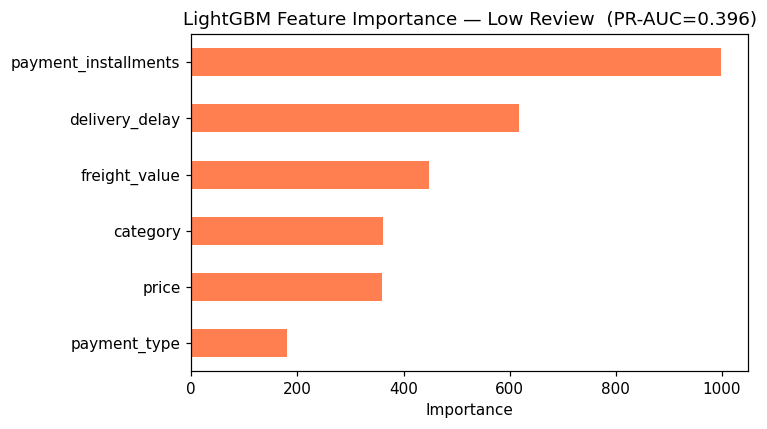

In [19]:
# ── review model feature importance ──────────────────────────────────────────
rev_imp = pd.Series(
    lgb_model.feature_importances_, index=Xr.columns
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(7, 4))
rev_imp.plot(kind="barh", ax=ax, color="coral")
ax.set_title(f"LightGBM Feature Importance — Low Review  (PR-AUC={rev_pr_auc:.3f})")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.savefig(MODELS_DIR / "review_feature_importance.png", bbox_inches="tight")
plt.show()

In [20]:
lgb_model.booster_.save_model(str(MODELS_DIR / "review_lgb.txt"))

rev_meta = {
    "feature_cols": list(Xr.columns),
    "cat_cols":     rev_cat_cols,
    "label":        "low_review (score <= 2)",
    "pr_auc":       round(rev_pr_auc, 4),
    "roc_auc":      round(rev_roc_auc, 4),
}
with open(MODELS_DIR / "review_meta.json", "w") as f:
    json.dump(rev_meta, f, indent=2)

with open(MODELS_DIR / "review_encoders.pkl", "wb") as f:
    pickle.dump(rev_encoders, f)

print("Saved: review_lgb.txt, review_meta.json, review_encoders.pkl")

Saved: review_lgb.txt, review_meta.json, review_encoders.pkl


## 11. Model Summary

In [21]:
summary = pd.DataFrame([
    {"model": "Churn Predictor",     "algorithm": "XGBoost",   "pr_auc": pr_auc,     "roc_auc": roc_auc},
    {"model": "Low Review Predictor","algorithm": "LightGBM",  "pr_auc": rev_pr_auc, "roc_auc": rev_roc_auc},
])
print(summary.to_string(index=False))
print("\nArtifacts in:", MODELS_DIR.resolve())
for f in sorted(MODELS_DIR.iterdir()):
    print(f"  {f.name}")

               model algorithm   pr_auc  roc_auc
     Churn Predictor   XGBoost 0.889713 0.683919
Low Review Predictor  LightGBM 0.396283 0.690594

Artifacts in: D:\Programming\Projects\E-commerce_project\models
  churn_encoders.pkl
  churn_eval.png
  churn_feature_importance.png
  churn_meta.json
  churn_xgb.json
  review_encoders.pkl
  review_feature_importance.png
  review_lgb.txt
  review_meta.json
